In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

In [2]:
import julia
from julia import Main
Main.eval("using QuadGK")
Main.eval('using Distributed')
Main.eval("using Roots")

In [3]:
Main.eval("""
    @everywhere begin
          
        using DelimitedFiles
        
        Grid1 = readdlm("../Grid/Γoverμ_1.csv", ',')
        Grid2 = readdlm("../Grid/Γoverμ_2.csv", ',')
        Grid3 = readdlm("../Grid/Γoverμ_3.csv", ',')
        Grid4 = readdlm("../Grid/Γoverμ_4.csv", ',')

        lnGrid1 = readdlm("../Grid/lnΓoverμ_1.csv", ',')
        lnGrid2 = readdlm("../Grid/lnΓoverμ_2.csv", ',')
        lnGrid3 = readdlm("../Grid/lnΓoverμ_3.csv", ',')
        lnGrid4 = readdlm("../Grid/lnΓoverμ_4.csv", ',')
          
        α1Grid = readdlm("../Grid/α1overμ.csv", ',')
        α2Grid = readdlm("../Grid/α2overμ.csv", ',')
        α3Grid = readdlm("../Grid/α3overμ.csv", ',')
        α4Grid = readdlm("../Grid/α4overμ.csv", ',')  
          
    end      
""")

Main.include("..\\strong coupling\\constants.jl")
Main.include("..\\strong coupling\\alpha_s.jl")
Main.include("..\\anomalous dim\\cusp\\cusp.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammaH.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammaB.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammaS.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammav.jl")
Main.include("..\\hard\\hard.jl")
Main.include("..\\jet\\jet.jl")
Main.include("..\\soft\\soft.jl")
Main.include("..\\ζ-prescription.jl")
Main.include("..\\Grid\\interpolation.jl")
#Main.include("..\\sigma.jl")

In [7]:
x=np.linspace(np.log(0.5),np.log(2500),5000)
print(np.exp(x))

[5.00000000e-01 5.00852616e-01 5.01706686e-01 ... 2.49149560e+03
 2.49574418e+03 2.50000000e+03]


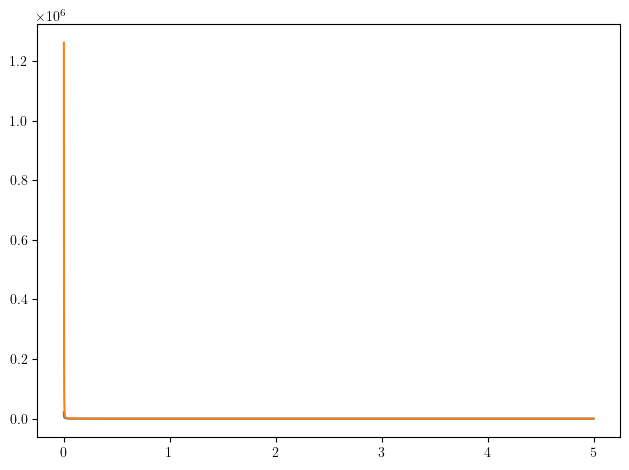

In [33]:
length = 1000

zero_points = np.zeros(length)
initial_scales = np.zeros(length)

b0 = 1.12292
b_list = np.exp(np.linspace(np.log(10**(-3)),np.log(5),length))

for index, bp in enumerate(b_list):
    BNP = 1.93
    bstar = bp/(1+(bp/BNP)**2)**0.5
    μf= 91.2#b0/bstar
    αs_J=Main.alpha_s_func(μf=μf, μi=91.2, αs=0.118, order=4, nf=5)
    D = -1/4*Main.D_grid(b=bp, μf=μf, αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=b0) + 0.04*bp*bstar
    zero_points[index] = Main.ζ_NP(D=D, μ=μf, αs=αs_J, order=3, nf=5)
    bstar2 = bp/(1+(bp/b0)**2)**0.5
    initial_scales[index] = (b0/bstar2)**2

#for index, bp in enumerate(b_list):
#    BNP = b0
#    bstar = bp/(1+(bp/BNP)**2)**0.5
#    #zero_points[index] = Main.saddle_μ(b=bp, αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=BNP, parameters=[0.0,0.0,0.08,1.123])
#    initial_scales[index] = 0.5*b0/bstar

plt.plot(b_list,zero_points,label="NP")
plt.plot(b_list,initial_scales,label="NP")
#plt.xlim(1,5)
#plt.ylim(0,2)

plt.tight_layout()  
plt.show()

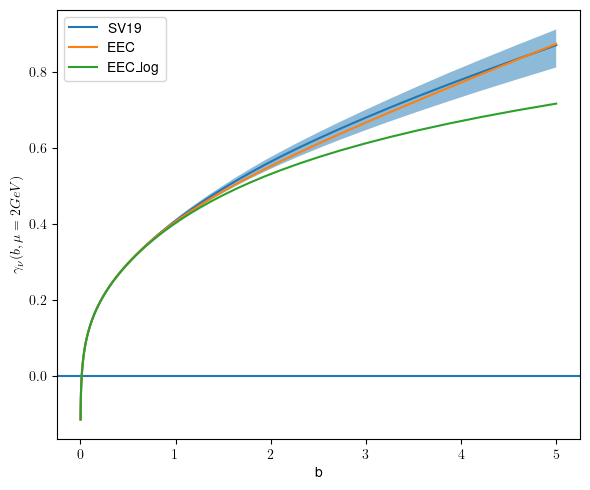

In [10]:
length = 100

globalfit = np.zeros(length)
globalup = np.zeros(length)
globaldown = np.zeros(length)

EECfit_bbstar = np.zeros(length)
EECup_bbstar = np.zeros(length)
EECdown_bbstar = np.zeros(length)

EECfit_log = np.zeros(length)
EECup_log = np.zeros(length)
EECdown_log = np.zeros(length)

b0 = 1.12292
b_list = np.exp(np.linspace(np.log(10**(-3)),np.log(5),length))

import pandas as pd
params = pd.read_csv("../data/SV19.csv")
for index, bp in enumerate(b_list):
    D_list=[]
    for i in range(100):
        BNP = params.iloc[i,0]
        c0 = params.iloc[i,1]
        bstar = bp/(1+(bp/BNP)**2)**0.5
        μ0 = 91.2
        D = -1/4*Main.D_grid(b=bp, μf=μ0, αs_ini=0.118, μ_ini=91.1876, order=3, nf=5, bmax=BNP) + c0*bp*bstar
        D_list.append(D)
    globalfit[index] = np.percentile(D_list,50)   
    globalup[index] = np.percentile(D_list,84)
    globaldown[index] = np.percentile(D_list,16)

for index, bp in enumerate(b_list):
    bmax = b0
    bstar = bp/(1+(bp/bmax)**2)**0.5
    μ0 = 91.2
    EECfit_bbstar[index] = -1/4*Main.D_grid(b=bp, μf=μ0, αs_ini=0.1173, μ_ini=91.1876, order=3, nf=5, bmax=bmax) + 0.086*bp*bstar
    EECup_bbstar[index] = -1/4*Main.D_grid(b=bp, μf=μ0, αs_ini=0.1173, μ_ini=91.1876, order=3, nf=5, bmax=bmax) + 0.086*bp*bstar
    EECdown_bbstar[index] = -1/4*Main.D_grid(b=bp, μf=μ0, αs_ini=0.1173, μ_ini=91.1876, order=3, nf=5, bmax=bmax) + 0.086*bp*bstar

for index, bp in enumerate(b_list):
    bmax = b0
    bstar = bp/(1+(bp/bmax)**2)**0.5
    μ0 = 91.2
    α = Main.alpha_s_func(μf=μ0, μi=91.1876, αs=0.117, order = 4, nf=5)
    EECfit_log[index] = -1/4*Main.D_grid(b=bp, μf=μ0, αs_ini=0.1173, μ_ini=91.1876, order=3, nf=5, bmax=bmax) + 0.207*np.log(bp/bstar)
    EECup_log[index] = -1/4*Main.D_grid(b=bp, μf=μ0, αs_ini=0.1173, μ_ini=91.1876, order=3, nf=5, bmax=bmax) + 0.207*np.log(bp/bstar)
    EECdown_log[index] = -1/4*Main.D_grid(b=bp, μf=μ0, αs_ini=0.1173, μ_ini=91.1876, order=3, nf=5, bmax=bmax) + 0.207*np.log(bp/bstar)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.axhline(0.0)

ax1.plot(b_list, globalfit, label="SV19")
ax1.fill_between(b_list, globaldown, globalup, alpha=0.5)

ax1.plot(b_list, EECfit_bbstar, label="EEC")
ax1.fill_between(b_list, EECdown_bbstar, EECup_bbstar, alpha=0.5)

ax1.plot(b_list, EECfit_log, label="EEC_log")
#ax1.fill_between(b_list, EECdown_log, EECup_log, alpha=0.5)

ax1.set_xlabel('b')
ax1.set_ylabel( r"\rm $ \gamma_\nu(b,\mu=2 GeV) $")
ax1.legend()
#plt.ylim(-0.1,0.66)
#plt.scatter([1.0,2.0,3.0,4.0],[-0.205,-0.566,0.828,-1.03])
#plt.ylim(-1.8,0.0)

plt.tight_layout()  
plt.show()

In [36]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)
v_4 = np.zeros(length)

w_1 = np.zeros(length)
w_2 = np.zeros(length)
w_3 = np.zeros(length)
w_4 = np.zeros(length)

x_1 = np.zeros(length)
x_2 = np.zeros(length)
x_3 = np.zeros(length)
x_4 = np.zeros(length)

b0 = 1.12292
bmax = b0
b_list = np.linspace(10**(-3),4,length)

α_list = np.zeros(length)
bstar_list = np.zeros(length)


for index, bp in enumerate(b_list):
    bstar_list[index] = bp/(1+(bp/b0)**2)**0.5
    α_list[index] = Main.alpha_s_func(μf=b0/bstar_list[index], μi=91.1876, αs=0.118, order = 4, nf=5)

for index, bp in enumerate(b_list):
    bstar_list[index] = bp/(1+(bp/b0)**2)**0.5 
    μ0 = 2*b0/bstar_list[index]
    v_1[index] = Main.γν_resum(b=bstar_list[index], μ0=μ0, αs=α_list[index], order=1, nf=5, bmax=bmax)
    v_2[index] = Main.γν_resum(b=bstar_list[index], μ0=μ0, αs=α_list[index], order=2, nf=5, bmax=bmax)
    v_3[index] = Main.γν_resum(b=bstar_list[index], μ0=μ0, αs=α_list[index], order=3, nf=5, bmax=bmax)
    #v_4[index] = Main.γν_resum(b=bstar_list[index], μ0=b0/bstar_list[index], αs=0.118, order=4, nf=5, bmax=bmax)

for index, bp in enumerate(b_list):
    bstar_list[index] = bp/(1+(bp/b0)**2)**0.5
    μ0 = 0.5*b0/bstar_list[index]
    w_1[index] = Main.D_grid(b=bp, μf=μ0, αs_ini=0.118, μ_ini=91.1876, order=1, nf=5, bmax=bmax)
    w_2[index] = Main.D_grid(b=bp, μf=μ0, αs_ini=0.118, μ_ini=91.1876, order=2, nf=5, bmax=bmax)
    w_3[index] = Main.D_grid(b=bp, μf=μ0, αs_ini=0.118, μ_ini=91.1876, order=3, nf=5, bmax=bmax)
    #w_4[index] = Main.D_grid(b=bp, μf=b0/bstar_list[index], αs_ini=0.118, μ_ini=91.1876, order=4, nf=5, bmax=bmax)

for index, bp in enumerate(b_list):
    bstar_list[index] = bp/(1+(bp/b0)**2)**0.5
    μ0 = 2*b0/bstar_list[index]
    x_1[index] = Main.γν_func(b=bstar_list[index], μ0=μ0, αs=α_list[index], order=1, nf=5, bmax=bmax)
    x_2[index] = Main.γν_func(b=bstar_list[index], μ0=μ0, αs=α_list[index], order=1, nf=5, bmax=bmax)
    x_3[index] = Main.γν_func(b=bstar_list[index], μ0=μ0, αs=α_list[index], order=2, nf=5, bmax=bmax)
    #x_4[index] = Main.γν_func(b=bstar_list[index], μ0=b0/bstar_list[index], αs=α_list[index], order=3, nf=5, bmax=bmax)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, v_1, label="1-loop Resummed", color="red")
ax1.plot(b_list, v_2, label="2-loop Resummed", color="orange")
ax1.plot(b_list, v_3, label="3-loop Resummed", color="blue")
#ax1.plot(b_list, v_4, label="4-loop Resummed", color="green")

ax1.plot(b_list, w_1, linestyle='dashed', color="red")
ax1.plot(b_list, w_2, linestyle='dashed', color="orange")
ax1.plot(b_list, w_3, linestyle='dashed', color="blue")
#ax1.plot(b_list, w_4, linestyle='dashed', color="green")

ax1.plot(b_list, x_1, linestyle='dotted', color="red")
ax1.plot(b_list, x_2, linestyle='dotted', color="orange")
ax1.plot(b_list, x_3, linestyle='dotted', color="blue")
#ax1.plot(b_list, x_4, linestyle='dotted', color="green")

ax1.set_xlabel('b')
ax1.set_ylabel( r"\rm $ \gamma_\nu(b,\mu=b0/b^*) $")
ax1.legend()

plt.tight_layout()  
plt.show()

IndexError: <PyCall.jlwrap (in a Julia function called from Python)
JULIA: BoundsError: attempt to access 3000×205 extrapolate(scale(interpolate(OffsetArray(::Matrix{Float64}, 0:3001, 0:206), BSpline(Cubic(Line(OnGrid())))), (-0.01005033585350145:0.0023674982232842925:7.090076835776092, 0.1129:5.0e-5:0.1231)), Throw()) with element type Float64 at index [-0.01050163628890636, 0.118]
Stacktrace:
 [1] throw_boundserror(A::Interpolations.Extrapolation{Float64, 2, ScaledInterpolation{Float64, 2, Interpolations.BSplineInterpolation{Float64, 2, OffsetArrays.OffsetMatrix{Float64, Matrix{Float64}}, BSpline{Cubic{Line{OnGrid}}}, Tuple{Base.OneTo{Int64}, Base.OneTo{Int64}}}, BSpline{Cubic{Line{OnGrid}}}, Tuple{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}}}, BSpline{Cubic{Line{OnGrid}}}, Throw{Nothing}}, I::Tuple{Float64, Float64})
   @ Base .\abstractarray.jl:737


AttributeError: γν_numerical

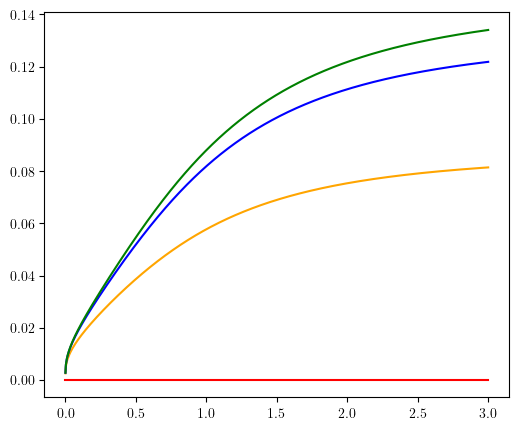

In [16]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)
v_4 = np.zeros(length)

b0 = 1.12292
bmax = b0
b_list = np.linspace(10**(-4),3,length)

for index, bp in enumerate(b_list):
    v_1[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=1, nf=5, bmax=bmax)
    v_2[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=2, nf=5, bmax=bmax)
    v_3[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=bmax)
    v_4[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=4, nf=5, bmax=bmax)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, v_1, label="1-loop", color="red")
ax1.plot(b_list, v_2, label="2-loop", color="orange")
ax1.plot(b_list, v_3, label="3-loop", color="blue")
ax1.plot(b_list, v_4, label="4-loop", color="green")

w_1 = np.zeros(length)
w_2 = np.zeros(length)
w_3 = np.zeros(length)
w_4 = np.zeros(length)

for index, bp in enumerate(b_list):
    w_1[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=1, nf=5, bmax=bmax)
    w_2[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=2, nf=5, bmax=bmax)
    w_3[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=bmax)
    w_4[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=4, nf=5, bmax=bmax)

ax1.plot(b_list, w_1, linestyle='dashed', color="red")
ax1.plot(b_list, w_2, linestyle='dashed', color="orange")
ax1.plot(b_list, w_3, linestyle='dashed', color="blue")
ax1.plot(b_list, w_4, linestyle='dashed', color="green")

ax1.set_xlabel('b')
ax1.set_ylabel( r"\rm $ \gamma_\nu(b,\mu=b0/b^*) $")
ax1.legend()

plt.ylim(-0.25,0.05)
plt.tight_layout()  
plt.show()

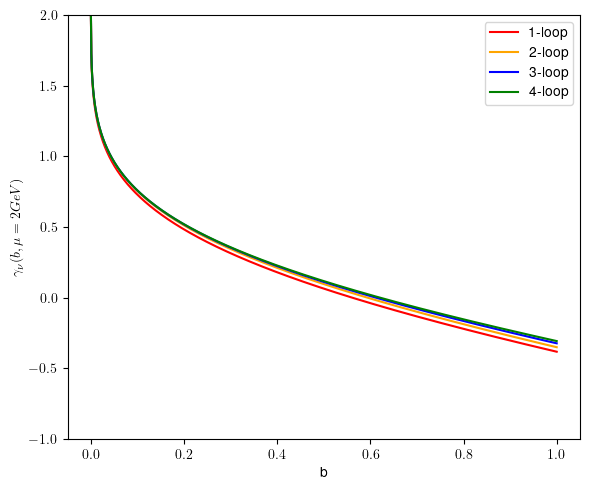

In [9]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)
v_4 = np.zeros(length)

b0 = 1.12292
bmax = b0
b_list = np.linspace(10**(-4),1,length)

for index, bp in enumerate(b_list):
    v_1[index] = Main.Integral_ν_numerical(b=bp, μf=2.0, αs_ini=0.118, μ_ini=91.2, order=1, nf=5, bmax=bmax)
    v_2[index] = Main.Integral_ν_numerical(b=bp, μf=2.0, αs_ini=0.118, μ_ini=91.2, order=2, nf=5, bmax=bmax)
    v_3[index] = Main.Integral_ν_numerical(b=bp, μf=2.0, αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=bmax)
    v_4[index] = Main.Integral_ν_numerical(b=bp, μf=2.0, αs_ini=0.118, μ_ini=91.2, order=4, nf=5, bmax=bmax)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, v_1, label="1-loop", color="red")
ax1.plot(b_list, v_2, label="2-loop", color="orange")
ax1.plot(b_list, v_3, label="3-loop", color="blue")
ax1.plot(b_list, v_4, label="4-loop", color="green")

ax1.set_xlabel('b')
ax1.set_ylabel( r"\rm $ \gamma_\nu(b,\mu=2GeV) $")
ax1.legend()

plt.ylim(-1,2)
plt.tight_layout()  
plt.show()

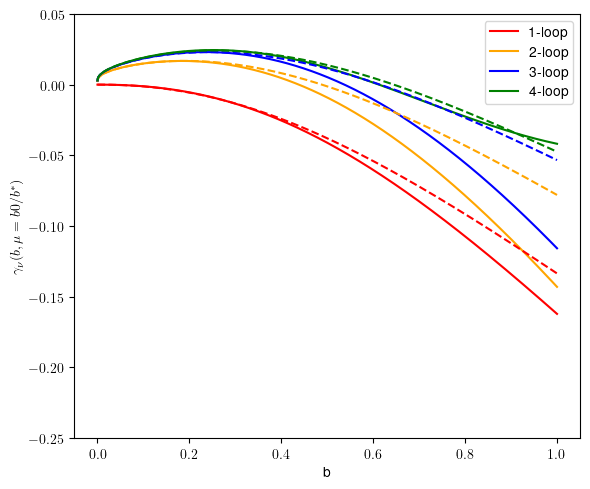

In [10]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)
v_4 = np.zeros(length)

b0 = 1.12292
bmax = b0
b_list = np.linspace(10**(-4),1,length)

for index, bp in enumerate(b_list):
    v_1[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=1, nf=5, bmax=bmax)
    v_2[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=2, nf=5, bmax=bmax)
    v_3[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=bmax)
    v_4[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=4, nf=5, bmax=bmax)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, v_1, label="1-loop", color="red")
ax1.plot(b_list, v_2, label="2-loop", color="orange")
ax1.plot(b_list, v_3, label="3-loop", color="blue")
ax1.plot(b_list, v_4, label="4-loop", color="green")

w_1 = np.zeros(length)
w_2 = np.zeros(length)
w_3 = np.zeros(length)
w_4 = np.zeros(length)

for index, bp in enumerate(b_list):
    w_1[index] = Main.Integral_ν_analytic(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=1, nf=5, bmax=bmax)
    w_2[index] = Main.Integral_ν_analytic(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=2, nf=5, bmax=bmax)
    w_3[index] = Main.Integral_ν_analytic(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=bmax)
    w_4[index] = Main.Integral_ν_analytic(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=4, nf=5, bmax=bmax)

ax1.plot(b_list, w_1, linestyle='dashed', color="red")
ax1.plot(b_list, w_2, linestyle='dashed', color="orange")
ax1.plot(b_list, w_3, linestyle='dashed', color="blue")
ax1.plot(b_list, w_4, linestyle='dashed', color="green")

ax1.set_xlabel('b')
ax1.set_ylabel( r"\rm $ \gamma_\nu(b,\mu=b0/b^*) $")
ax1.legend()

plt.ylim(-0.25,0.05)
plt.tight_layout()  
plt.show()

In [ ]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)
v_4 = np.zeros(length)

b0 = 1.12292
bmax = b0
b_list = np.linspace(10**(-4),1,length)

for index, bp in enumerate(b_list):
    v_1[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=1, nf=5, bmax=bmax)
    v_2[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=2, nf=5, bmax=bmax)
    v_3[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=bmax)
    v_4[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=4, nf=5, bmax=bmax)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, v_1, label="1-loop", color="red")
ax1.plot(b_list, v_2, label="2-loop", color="orange")
ax1.plot(b_list, v_3, label="3-loop", color="blue")
ax1.plot(b_list, v_4, label="4-loop", color="green")

w_1 = np.zeros(length)
w_2 = np.zeros(length)
w_3 = np.zeros(length)
w_4 = np.zeros(length)

for index, bp in enumerate(b_list):
    w_1[index] = Main.Integral_ν_analytic(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=1, nf=5, bmax=bmax)
    w_2[index] = Main.Integral_ν_analytic(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=2, nf=5, bmax=bmax)
    w_3[index] = Main.Integral_ν_analytic(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=bmax)
    w_4[index] = Main.Integral_ν_analytic(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=4, nf=5, bmax=bmax)

ax1.plot(b_list, w_1, linestyle='dashed', color="red")
ax1.plot(b_list, w_2, linestyle='dashed', color="orange")
ax1.plot(b_list, w_3, linestyle='dashed', color="blue")
ax1.plot(b_list, w_4, linestyle='dashed', color="green")

ax1.set_xlabel('b')
ax1.set_ylabel( r"\rm $ \gamma_\nu(b,\mu=b0/b^*) $")
ax1.legend()

plt.ylim(-0.25,0.05)
plt.tight_layout()  
plt.show()

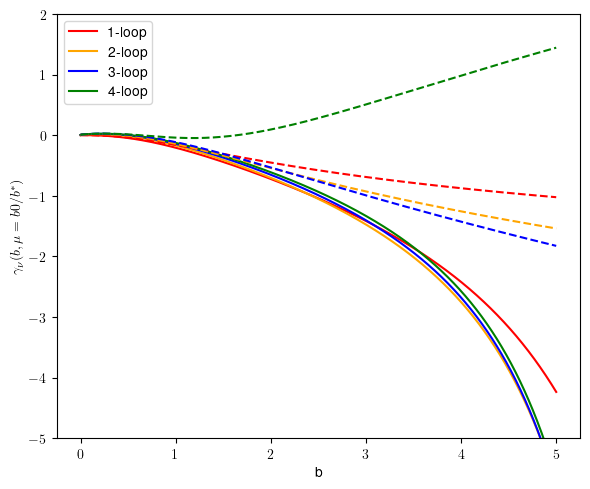

In [41]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)
v_4 = np.zeros(length)

b0 = 1.12292
bmax = b0
b_list = np.linspace(10**(-4),5,length)

for index, bp in enumerate(b_list):
    v_1[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=1, nf=5, bmax=bmax)
    v_2[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=2, nf=5, bmax=bmax)
    v_3[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=bmax)
    v_4[index] = Main.Integral_ν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=4, nf=5, bmax=bmax)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, v_1, label="1-loop", color="red")
ax1.plot(b_list, v_2, label="2-loop", color="orange")
ax1.plot(b_list, v_3, label="3-loop", color="blue")
ax1.plot(b_list, v_4, label="4-loop", color="green")

w_1 = np.zeros(length)
w_2 = np.zeros(length)
w_3 = np.zeros(length)
w_4 = np.zeros(length)

for index, bp in enumerate(b_list):
    w_1[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=1, nf=5, bmax=bmax)
    w_2[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=2, nf=5, bmax=bmax)
    w_3[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=bmax)
    w_4[index] = Main.γν_numerical(b=bp, μf=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=4, nf=5, bmax=bmax)

ax1.plot(b_list, w_1, linestyle='dashed', color="red")
ax1.plot(b_list, w_2, linestyle='dashed', color="orange")
ax1.plot(b_list, w_3, linestyle='dashed', color="blue")
ax1.plot(b_list, w_4, linestyle='dashed', color="green")

ax1.set_xlabel('b')
ax1.set_ylabel( r"\rm $ \gamma_\nu(b,\mu=b0/b^*) $")
ax1.legend()

plt.ylim(-5,2)
plt.tight_layout()  
plt.show()

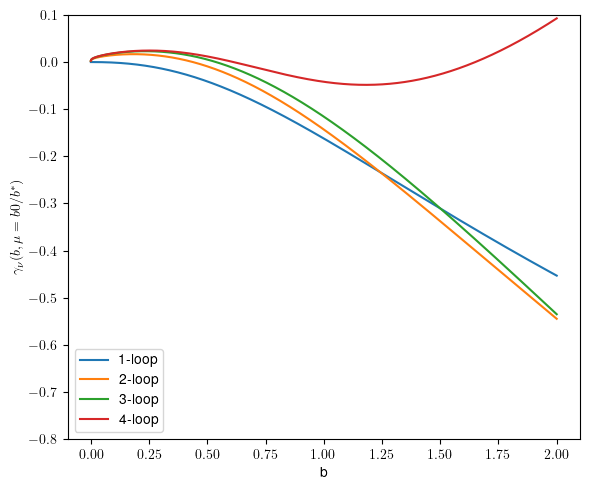

In [22]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)
v_4 = np.zeros(length)

b0 = 1.12292
bmax = b0
b_list = np.linspace(10**(-4),2,length)

ax1.set_xlabel('b')
ax1.set_ylabel( r"\rm $ \gamma_\nu(b,\mu=b0/b^*) $")
ax1.legend()

plt.ylim(-0.8,0.1)
plt.tight_layout()  
plt.show()

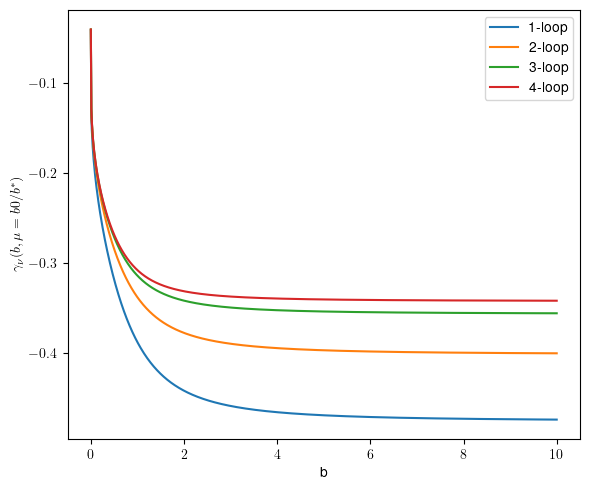

In [16]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)
v_4 = np.zeros(length)

b0 = 1.12292
bmax = b0
b_list = np.linspace(10**(-9),10,length)

α_list = np.zeros(length)

for index, bp in enumerate(b_list):
    α_list[index] = Main.alpha_s_func(μf=b0/(bp/(1+(bp/bmax)**2)**0.5), μi=91.1876, αs=0.118, order = 4, nf=5)

for index, bp in enumerate(b_list):
    v_1[index] = Main.γν_raw(αs=α_list[index],  order=1, nf=5) + Main.γν_final(b=bp, μB=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=1, nf=5, bmax=bmax)
    v_2[index] = Main.γν_raw(αs=α_list[index],  order=2, nf=5) + Main.γν_final(b=bp, μB=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=2, nf=5, bmax=bmax)
    v_3[index] = Main.γν_raw(αs=α_list[index],  order=3, nf=5) + Main.γν_final(b=bp, μB=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=bmax)
    v_4[index] = Main.γν_raw(αs=α_list[index],  order=4, nf=5) + Main.γν_final(b=bp, μB=b0/(bp/(1+(bp/bmax)**2)**0.5), αs_ini=0.118, μ_ini=91.2, order=4, nf=5, bmax=bmax)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, v_1, label="1-loop")
ax1.plot(b_list, v_2, label="2-loop")
ax1.plot(b_list, v_3, label="3-loop")
ax1.plot(b_list, v_4, label="4-loop")
ax1.set_xlabel('b')
ax1.set_ylabel( r"\rm $ \gamma_\nu(b,\mu=b0/b^*) $")
ax1.legend()

plt.tight_layout()  
plt.show()

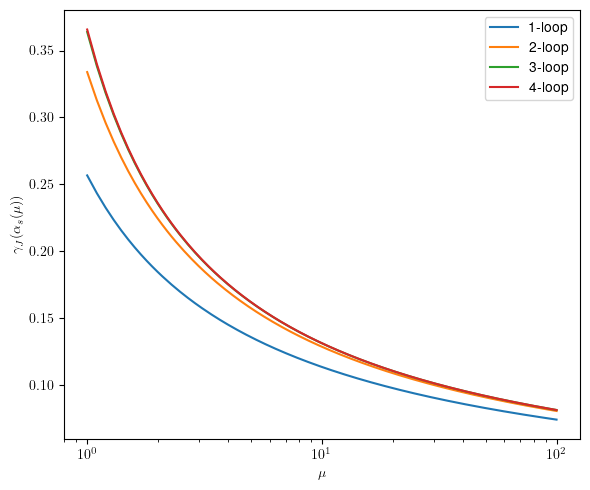

In [81]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)

b0 = 1.12292
mu_list = np.linspace(1,100,length)
α_list = np.zeros(length)

for index, mu in enumerate(mu_list):
    α_list[index] = Main.alpha_s_func(μf=float(mu), μi=91.1876, αs=0.118, order = 4, nf=5)

for index, α in enumerate(α_list):    
    v_1[index] = Main.γB_tilde(αs=float(α),order=1,nf=5)
    v_2[index] = Main.γB_tilde(αs=float(α), order=2, nf=5)
    v_3[index] = Main.γB_tilde(αs=float(α), order=3, nf=5)
    v_4[index] = Main.γB_tilde(αs=float(α), order=4, nf=5)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(mu_list, v_1, label="1-loop")
ax1.plot(mu_list, v_2, label="2-loop")
ax1.plot(mu_list, v_3, label="3-loop")
ax1.plot(mu_list, v_4, label="4-loop")
ax1.set_xlabel(r"\rm $\mu$")
ax1.set_ylabel( r"\rm $ \gamma_J(\alpha_s(\mu)) $")
ax1.set_xscale("log")
ax1.legend()

plt.tight_layout()  
plt.show()

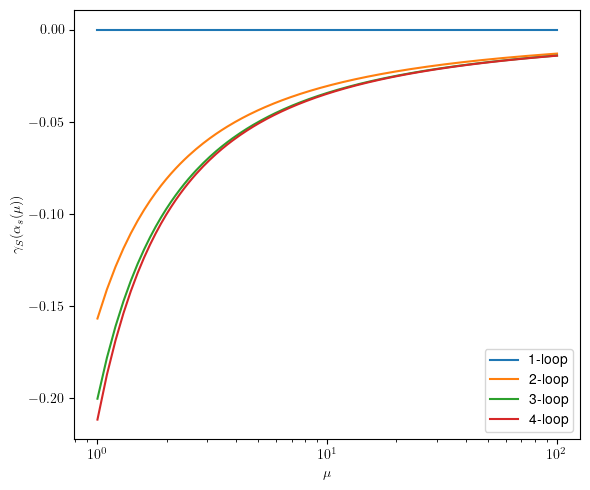

In [77]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)

b0 = 1.12292
mu_list = np.linspace(1,100,length)
α_list = np.zeros(length)

for index, mu in enumerate(mu_list):
    bstar = bp/(1+(bp/b0)**2)**0.5
    μ0 = b0/bstar
    α_list[index] = Main.alpha_s_func(μf=float(mu), μi=91.1876, αs=0.118, order = 4, nf=5)

for index, α in enumerate(α_list):    
    v_1[index] = Main.γS_tilde(αs=float(α),order=1,nf=5)
    v_2[index] = Main.γS_tilde(αs=float(α), order=2, nf=5)
    v_3[index] = Main.γS_tilde(αs=float(α), order=3, nf=5)
    v_4[index] = Main.γS_tilde(αs=float(α), order=4, nf=5)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(mu_list, v_1, label="1-loop")
ax1.plot(mu_list, v_2, label="2-loop")
ax1.plot(mu_list, v_3, label="3-loop")
ax1.plot(mu_list, v_4, label="4-loop")
ax1.set_xlabel(r"\rm $\mu$")
ax1.set_ylabel( r"\rm $ \gamma_S(\alpha_s(\mu)) $")
ax1.set_xscale("log")
ax1.legend()

plt.tight_layout()  
plt.show()

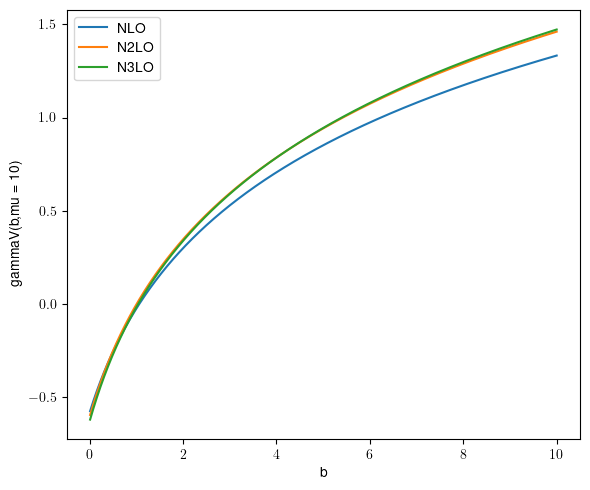

In [46]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)

b0 = 1.12292
mu_list = np.linspace(0.9,10,length)

for index, mu in enumerate(mu_list):
    v_1[index] = Main.γH_final(Q=mu, μ=1.0, αs_ini=0.118, μ_ini=91.2, order=1, nf=5)
    v_2[index] = Main.γH_final(Q=mu, μ=1.0, αs_ini=0.118, μ_ini=91.2, order=2, nf=5)
    v_3[index] = Main.γH_final(Q=mu, μ=1.0, αs_ini=0.118, μ_ini=91.2, order=3, nf=5)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, v_1, label="NLO")
ax1.plot(b_list, v_2, label="N2LO")
ax1.plot(b_list, v_3, label="N3LO")
ax1.set_xlabel('b')
ax1.set_ylabel('gammaV(b,mu = 10)')
ax1.legend()

plt.tight_layout()  
plt.show()

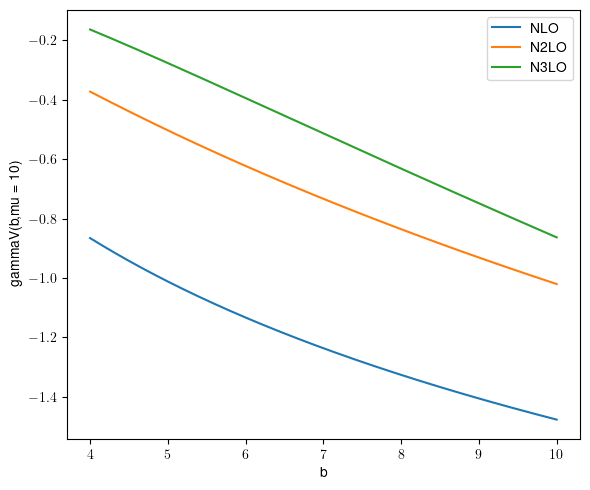

In [91]:
length = 1000

v_1 = np.zeros(length)
v_2 = np.zeros(length)
v_3 = np.zeros(length)

b0 = 1.12292
b_list = np.linspace(4,10,length)

for index, bp in enumerate(b_list):
    bstar = bp/(1+(bp/b0)**2)**0.5
    μ0 = b0/bstar
    α = Main.alpha_s_func(μf=μ0, μi=91.2, αs=0.118, order=3, nf=5)
    v_1[index] = (α/(4*3.14))*Main.γν1_final(np.log((bp*μ0/b0)**2),5)
    v_2[index] = (α/(4*3.14))**2*Main.γν2_final(np.log((bp*μ0/b0)**2),5)
    v_3[index] = (α/(4*3.14))**3*Main.γν3_final(np.log((bp*μ0/b0)**2),5)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, v_1, label="NLO")
ax1.plot(b_list, v_2, label="N2LO")
ax1.plot(b_list, v_3, label="N3LO")
ax1.set_xlabel('b')
ax1.set_ylabel('gammaV(b,mu = 10)')
ax1.legend()

plt.tight_layout()  
plt.show()